# FreqLoRA-SAM v2: Band-Grouped Gating + Joint Training (Phase 1)

**Two changes from v1:**
1. **Architecture**: Band-grouped gating (3 gates per layer: low/mid/high frequency)
2. **Data**: Train on Kvasir-SEG + CVC-ClinicDB jointly (~1450 images)

**Phase 1**: Quick validation run — 3 modes × 1 seed (seed=42) to verify the approach works before committing to the full 3×5 run.

**Cross-dataset test**: CVC-ColonDB + ETIS-LaribPolypDB (never seen during training)


In [1]:
# ============================================================
# Cell 1 — Install + imports
# ============================================================
!pip -q install git+https://github.com/ChaoningZhang/MobileSAM.git
!pip -q install scipy

import os, sys, random, gc, math, time, warnings, glob
from collections import OrderedDict
from pathlib import Path

import numpy as np
import cv2
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import distance_transform_edt
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.amp import autocast, GradScaler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from mobile_sam import sam_model_registry
from mobile_sam.utils.transforms import ResizeLongestSide

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"DEVICE: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} | "
          f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


  Preparing metadata (setup.py) ... done
DEVICE: cuda
GPU: Tesla T4 | VRAM: 15.64 GB


In [2]:
# ============================================================
# Cell 2 — Paths + hyperparameters
# ============================================================
# --- Training datasets (Kvasir-SEG + CVC-ClinicDB) ---
KVASIR_ROOT = "/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG"
KVASIR_IMG = os.path.join(KVASIR_ROOT, "images")
KVASIR_MSK = os.path.join(KVASIR_ROOT, "masks")

CLINIC_IMG = "/kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Original"
CLINIC_MSK = "/kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Ground Truth"

TINY_CKPT = "/kaggle/input/models/haryshwa/tiny-sam/tensorflow2/default/1/mobile_sam.pt"

# --- Cross-dataset evaluation ---
CROSS_DATASETS = OrderedDict({
    'CVC-ColonDB': {
        'img_dir': '/kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/images',
        'mask_dir': '/kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/masks',
    },
    'ETIS-LaribPolypDB': {
        'img_dir': '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/images',
        'mask_dir': '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/masks',
    },
})

# Verify paths
for name, path in [("Kvasir IMG", KVASIR_IMG), ("Kvasir MSK", KVASIR_MSK),
                    ("ClinicDB IMG", CLINIC_IMG), ("ClinicDB MSK", CLINIC_MSK),
                    ("MobileSAM", TINY_CKPT)]:
    ok = os.path.exists(path)
    print(f"  {'OK' if ok else 'MISSING'}: {name} -> {path}")
    assert ok, f"Not found: {path}"

for ds_name, p in CROSS_DATASETS.items():
    ok = os.path.isdir(p['img_dir'])
    print(f"  {'OK' if ok else 'MISSING'}: {ds_name}")

# --- Hyperparameters ---
SAM_IMG_SIZE   = 1024
LORA_RANK      = 4
LORA_ALPHA     = 1.0
LORA_DROPOUT   = 0.05
LR_LORA        = 3e-4
LR_OTHER       = 8e-5
WEIGHT_DECAY   = 0.01
EPOCHS         = 30
WARMUP_EPOCHS  = 5
PATIENCE       = 20
GRAD_ACCUM     = 4
MAX_GRAD_NORM  = 1.0
BOUNDARY_WEIGHT = 0.5
N_FG_POINTS    = 2
N_BG_POINTS    = 1
EVAL_SEED      = 9999  # Fixed seed for evaluation point sampling

# Phase 1: single seed
TRAIN_SEED     = 42

print(f"\nHyperparameters set. Phase 1: seed={TRAIN_SEED}")


  OK: Kvasir IMG -> /kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG/images
  OK: Kvasir MSK -> /kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG/masks
  OK: ClinicDB IMG -> /kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Original
  OK: ClinicDB MSK -> /kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Ground Truth
  OK: MobileSAM -> /kaggle/input/models/haryshwa/tiny-sam/tensorflow2/default/1/mobile_sam.pt
  OK: CVC-ColonDB
  OK: ETIS-LaribPolypDB

Hyperparameters set. Phase 1: seed=42


In [3]:
# ============================================================
# Cell 3 — Band-Grouped FreqLoRA adapter (NEW architecture)
# ============================================================
class BandGroupedFreqLoRALinear(nn.Module):
    """
    FreqLoRA with band-grouped gating.
    
    Changes from v1:
    - 3 gate scalars per layer (low/mid/high frequency bands) instead of 1
    - Each gate independently controls spatial vs frequency contribution
      for its frequency band
    - Everything else identical to v1
    """
    def __init__(self, original_linear: nn.Linear, rank: int = 4,
                 alpha: float = 1.0, dropout: float = 0.0, mode: str = "freqlora"):
        super().__init__()
        self.in_features = original_linear.in_features
        self.out_features = original_linear.out_features
        self.rank = rank
        self.scaling = alpha / rank
        self.mode = mode

        # Frozen original weights
        self.linear = original_linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        # Spatial pathway (standard LoRA)
        self.lora_A_spatial = nn.Linear(self.in_features, rank, bias=False)
        self.lora_B_spatial = nn.Linear(rank, self.out_features, bias=False)

        # Frequency pathway
        self.n_freq_bins = self.in_features // 2 + 1
        self.spectral_filter = nn.Parameter(torch.ones(self.n_freq_bins))
        self.lora_A_freq = nn.Linear(self.in_features, rank, bias=False)
        self.lora_B_freq = nn.Linear(rank, self.out_features, bias=False)

        # Band-grouped gates (NEW: 3 instead of 1)
        # Divide frequency bins into 3 equal groups
        self.band_size = self.n_freq_bins // 3
        self.gate_low  = nn.Parameter(torch.tensor(0.0))   # bins [0, band_size)
        self.gate_mid  = nn.Parameter(torch.tensor(0.0))   # bins [band_size, 2*band_size)
        self.gate_high = nn.Parameter(torch.tensor(0.0))   # bins [2*band_size, n_freq_bins)

        # Dropout
        self.lora_dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # Init
        nn.init.kaiming_uniform_(self.lora_A_spatial.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B_spatial.weight)
        nn.init.kaiming_uniform_(self.lora_A_freq.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B_freq.weight)

    def _build_band_gate_mask(self):
        """Build a per-feature gate mask from the 3 band gates.
        
        The idea: after iFFT reconstructs the features, different parts of the 
        reconstructed vector are influenced by different frequency bands.
        We create a smooth blending mask across the feature dimension that 
        assigns low/mid/high gate values to corresponding regions.
        """
        g_low  = torch.sigmoid(self.gate_low)
        g_mid  = torch.sigmoid(self.gate_mid)
        g_high = torch.sigmoid(self.gate_high)
        
        # Build gate vector in frequency domain, then iFFT to get spatial-domain mask
        # Simpler and more direct: create a weight per freq bin based on its band
        freq_gates = torch.zeros(self.n_freq_bins, device=self.gate_low.device)
        b = self.band_size
        freq_gates[:b] = g_low
        freq_gates[b:2*b] = g_mid
        freq_gates[2*b:] = g_high
        
        return g_low, g_mid, g_high, freq_gates

    def forward(self, x):
        base_out = self.linear(x)
        x_drop = self.lora_dropout(x)

        if self.mode == "spatial":
            lora_out = self.lora_B_spatial(self.lora_A_spatial(x_drop)) * self.scaling

        elif self.mode == "freq_only":
            x_drop_f32 = x_drop.float()
            x_freq = torch.fft.rfft(x_drop_f32, dim=-1)
            x_freq = x_freq * self.spectral_filter
            x_filtered = torch.fft.irfft(x_freq, n=self.in_features, dim=-1).to(x_drop.dtype)
            lora_out = self.lora_B_freq(self.lora_A_freq(x_filtered)) * self.scaling

        else:  # "freqlora" — band-grouped dual pathway
            # Spatial pathway
            spatial_out = self.lora_B_spatial(self.lora_A_spatial(x_drop)) * self.scaling

            # Frequency pathway with band-grouped gating
            x_drop_f32 = x_drop.float()
            x_freq = torch.fft.rfft(x_drop_f32, dim=-1)
            
            # Apply spectral filter
            x_filtered_freq = x_freq * self.spectral_filter
            
            # Apply band-specific gates IN frequency domain before iFFT
            # Gate controls: high gate value = more spatial, low gate value = more frequency
            # So we weight the frequency contribution by (1 - gate) per band
            g_low, g_mid, g_high, freq_gates = self._build_band_gate_mask()
            
            # Spatial gate weights (how much spatial contributes per band)
            # We blend in frequency domain: keep freq signal scaled by (1-gate)
            spatial_gate_freq = freq_gates  # gate values per bin
            freq_weight = 1.0 - freq_gates  # frequency pathway weight per bin
            
            # Scale frequency-domain signal by per-band frequency weight
            x_freq_gated = x_filtered_freq * freq_weight.unsqueeze(0) if x_filtered_freq.dim() == 2 else x_filtered_freq * freq_weight
            
            # iFFT back to feature space
            x_filtered = torch.fft.irfft(x_freq_gated, n=self.in_features, dim=-1).to(x_drop.dtype)
            freq_out = self.lora_B_freq(self.lora_A_freq(x_filtered)) * self.scaling
            
            # Spatial contribution: gated by mean of band gates
            # (spatial gets the complement of what frequency gets)
            mean_spatial_gate = (g_low + g_mid + g_high) / 3.0
            lora_out = mean_spatial_gate * spatial_out + freq_out

        return base_out + lora_out


def inject_adapters(model, rank=4, alpha=1.0, dropout=0.0, mode="freqlora"):
    """Replace all nn.Linear layers with BandGroupedFreqLoRALinear."""
    targets = []
    for name, module in model.named_modules():
        for child_name, child in module.named_children():
            if not isinstance(child, nn.Linear):
                continue
            full_name = f"{name}.{child_name}" if name else child_name
            targets.append((module, child_name, child, full_name))
    injected = []
    for parent, child_name, child, full_name in targets:
        layer = BandGroupedFreqLoRALinear(child, rank=rank, alpha=alpha, dropout=dropout, mode=mode)
        setattr(parent, child_name, layer)
        injected.append((full_name, layer))
    return injected

print(f"BandGroupedFreqLoRALinear defined.")
print(f"  For dim=160: {160//2+1} freq bins, band_size={160//2+1 // 3}, 3 gates per layer")
print(f"  For dim=320: {320//2+1} freq bins, band_size={320//2+1 // 3}, 3 gates per layer")


BandGroupedFreqLoRALinear defined.
  For dim=160: 81 freq bins, band_size=80, 3 gates per layer
  For dim=320: 161 freq bins, band_size=160, 3 gates per layer


In [4]:
# ============================================================
# Cell 4 — Data augmentation
# ============================================================
def augment_image_mask(image, mask, p_flip=0.5, p_rot=0.5, p_color=0.5,
                       p_elastic=0.3, p_scale=0.3):
    H, W = mask.shape

    if random.random() < p_flip:
        image = np.flip(image, axis=1).copy()
        mask  = np.flip(mask, axis=1).copy()

    if random.random() < p_flip:
        image = np.flip(image, axis=0).copy()
        mask  = np.flip(mask, axis=0).copy()

    if random.random() < p_rot:
        k = random.choice([1, 2, 3])
        image = np.rot90(image, k).copy()
        mask  = np.rot90(mask, k).copy()
        H, W = mask.shape

    if random.random() < p_scale:
        s = random.uniform(0.8, 1.2)
        nH, nW = int(H * s), int(W * s)
        image = cv2.resize(image, (nW, nH), interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask, (nW, nH), interpolation=cv2.INTER_NEAREST)
        if nH < H or nW < W:
            pad_h = max(0, H - nH)
            pad_w = max(0, W - nW)
            image = np.pad(image, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
            mask  = np.pad(mask, ((0, pad_h), (0, pad_w)), mode='reflect')
        image = image[:H, :W]
        mask  = mask[:H, :W]

    if random.random() < p_elastic:
        from scipy.ndimage import gaussian_filter, map_coordinates
        sigma, alpha_e = 6, 80
        dx = gaussian_filter(np.random.randn(H, W), sigma) * alpha_e
        dy = gaussian_filter(np.random.randn(H, W), sigma) * alpha_e
        y, x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
        coords = [np.clip(y + dy, 0, H - 1), np.clip(x + dx, 0, W - 1)]
        for c in range(3):
            image[:, :, c] = map_coordinates(image[:, :, c], coords, order=1, mode='reflect')
        mask = map_coordinates(mask, coords, order=0, mode='reflect')

    if random.random() < p_color:
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:, :, 0] = np.clip(hsv[:, :, 0] + random.uniform(-10, 10), 0, 179)
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * random.uniform(0.8, 1.2), 0, 255)
        hsv[:, :, 2] = np.clip(hsv[:, :, 2] * random.uniform(0.8, 1.2), 0, 255)
        image = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    return image, mask

print("Augmentation defined.")


Augmentation defined.


In [5]:
# ============================================================
# Cell 5 — Point sampling (with fixed seed option for eval)
# ============================================================
def sample_points(mask01, n_fg=2, n_bg=1):
    H, W = mask01.shape
    ys_fg, xs_fg = np.where(mask01 > 0.5)
    ys_bg, xs_bg = np.where(mask01 <= 0.5)

    if len(xs_fg) == 0:
        idx = np.random.choice(len(xs_bg), size=n_fg + n_bg, replace=True)
        pts = np.stack([xs_bg[idx], ys_bg[idx]], axis=1).astype(np.float32)
        labels = np.array([1]*n_fg + [0]*n_bg, dtype=np.int64)
        return pts, labels

    fg_pts = [[float(xs_fg.mean()), float(ys_fg.mean())]]
    if n_fg > 1:
        idx = np.random.choice(len(xs_fg), size=n_fg - 1, replace=True)
        for j in idx:
            fg_pts.append([float(xs_fg[j]), float(ys_fg[j])])

    bg_pts = []
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    dilated = cv2.dilate(mask01.astype(np.uint8), kernel, iterations=3)
    near_bg = (dilated > 0) & (mask01 <= 0.5)
    nby, nbx = np.where(near_bg)
    if len(nbx) >= n_bg:
        nidx = np.random.choice(len(nbx), size=n_bg, replace=False)
        for j in nidx:
            bg_pts.append([float(nbx[j]), float(nby[j])])
    elif len(xs_bg) > 0:
        idx = np.random.choice(len(xs_bg), size=n_bg, replace=True)
        for j in idx:
            bg_pts.append([float(xs_bg[j]), float(ys_bg[j])])
    else:
        bg_pts = [[0.0, 0.0]] * n_bg

    all_pts = np.array(fg_pts + bg_pts, dtype=np.float32)
    labels = np.array([1]*len(fg_pts) + [0]*len(bg_pts), dtype=np.int64)
    all_pts[:, 0] = np.clip(all_pts[:, 0], 0, W - 1)
    all_pts[:, 1] = np.clip(all_pts[:, 1], 0, H - 1)
    return all_pts, labels

print("Point sampling defined.")


Point sampling defined.


In [6]:
# ============================================================
# Cell 6 — Dataset class + Joint Kvasir+ClinicDB data loading
# ============================================================
sam_transform = ResizeLongestSide(SAM_IMG_SIZE)
IMG_EXT = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

class PolypDataset(Dataset):
    def __init__(self, img_dir, msk_dir, augment=False, fixed_seed=None):
        self.img_dir = img_dir
        self.msk_dir = msk_dir
        self.augment = augment
        self.fixed_seed = fixed_seed  # If set, use deterministic point sampling
        
        img_files = sorted(f for f in os.listdir(img_dir) if Path(f).suffix.lower() in IMG_EXT)
        msk_files = sorted(f for f in os.listdir(msk_dir) if Path(f).suffix.lower() in IMG_EXT)
        
        img_stems = {Path(f).stem: f for f in img_files}
        msk_stems = {Path(f).stem: f for f in msk_files}
        common = sorted(set(img_stems) & set(msk_stems))
        
        if common:
            self.pairs = [(img_stems[s], msk_stems[s]) for s in common]
        else:
            n = min(len(img_files), len(msk_files))
            self.pairs = list(zip(img_files[:n], msk_files[:n]))
        assert len(self.pairs) > 0, f"No image-mask pairs found in {img_dir}"

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name, msk_name = self.pairs[idx]
        image = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, img_name)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.msk_dir, msk_name), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = cv2.cvtColor(cv2.imread(os.path.join(self.msk_dir, msk_name)), cv2.COLOR_BGR2GRAY)
        mask01 = (mask > 127).astype(np.float32)

        if self.augment:
            image, mask01 = augment_image_mask(image, mask01)
            mask01 = (mask01 > 0.5).astype(np.float32)

        H, W = mask01.shape[:2]
        
        # Fixed seed for deterministic eval
        if self.fixed_seed is not None:
            rng_state = np.random.get_state()
            np.random.seed(self.fixed_seed + idx)
            pts_xy, pt_labels = sample_points(mask01, N_FG_POINTS, N_BG_POINTS)
            np.random.set_state(rng_state)
        else:
            pts_xy, pt_labels = sample_points(mask01, N_FG_POINTS, N_BG_POINTS)

        image_resized = sam_transform.apply_image(image)
        pts_resized = sam_transform.apply_coords(pts_xy, (H, W))

        image_t = torch.as_tensor(image_resized, dtype=torch.float32).permute(2, 0, 1)
        points_t = torch.as_tensor(pts_resized, dtype=torch.float32)
        labels_t = torch.as_tensor(pt_labels, dtype=torch.int64)
        mask_t = torch.as_tensor(mask01, dtype=torch.float32)

        return image_t, points_t, labels_t, mask_t, (H, W), img_name

# --- Build joint dataset ---
random.seed(TRAIN_SEED)
np.random.seed(TRAIN_SEED)
torch.manual_seed(TRAIN_SEED)

# Load both datasets
kvasir_ds = PolypDataset(KVASIR_IMG, KVASIR_MSK)
clinic_ds = PolypDataset(CLINIC_IMG, CLINIC_MSK)
print(f"Kvasir-SEG: {len(kvasir_ds)} images")
print(f"CVC-ClinicDB: {len(clinic_ds)} images")

# Combine and split 80/10/10
all_indices = list(range(len(kvasir_ds) + len(clinic_ds)))
combined_ds_raw = ConcatDataset([kvasir_ds, clinic_ds])
total = len(combined_ds_raw)

random.shuffle(all_indices)
n_train = int(0.8 * total)
n_val = int(0.1 * total)
n_test = total - n_train - n_val

train_idx = all_indices[:n_train]
val_idx = all_indices[n_train:n_train + n_val]
test_idx = all_indices[n_train + n_val:]

print(f"\nCombined: {total} images")
print(f"  Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

# Create subsets with augmentation for train
from torch.utils.data import Subset

class AugmentedSubset(Dataset):
    def __init__(self, base_dataset, indices, augment=False, fixed_seed=None):
        self.base = base_dataset
        self.indices = indices
        self.augment = augment
        self.fixed_seed = fixed_seed
        
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        # Get the underlying dataset and local index
        ds_idx = real_idx
        for ds in self.base.datasets:
            if ds_idx < len(ds):
                # Temporarily set augment
                old_aug = ds.augment
                old_seed = ds.fixed_seed
                ds.augment = self.augment
                ds.fixed_seed = self.fixed_seed
                item = ds[ds_idx]
                ds.augment = old_aug
                ds.fixed_seed = old_seed
                return item
            ds_idx -= len(ds)

train_set = AugmentedSubset(combined_ds_raw, train_idx, augment=True)
val_set = AugmentedSubset(combined_ds_raw, val_idx, augment=False, fixed_seed=EVAL_SEED)
test_set = AugmentedSubset(combined_ds_raw, test_idx, augment=False, fixed_seed=EVAL_SEED)

train_loader = DataLoader(train_set, batch_size=1, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

# Cross-dataset loaders (fixed seed for deterministic eval)
cross_loaders = OrderedDict()
for ds_name, paths in CROSS_DATASETS.items():
    ds = PolypDataset(paths['img_dir'], paths['mask_dir'], fixed_seed=EVAL_SEED)
    cross_loaders[ds_name] = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
    print(f"  Cross-dataset {ds_name}: {len(ds)} images")

print("\nAll data loaders ready.")


Kvasir-SEG: 1000 images
CVC-ClinicDB: 612 images

Combined: 1612 images
  Train: 1289, Val: 161, Test: 162
  Cross-dataset CVC-ColonDB: 380 images
  Cross-dataset ETIS-LaribPolypDB: 196 images

All data loaders ready.


In [7]:
# ============================================================
# Cell 7 — Loss functions
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * ((1 - pt) ** self.gamma) * bce).mean()


class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        inter = (probs * targets).sum()
        union = probs.sum() + targets.sum()
        return 1.0 - (2.0 * inter + self.smooth) / (union + self.smooth)


def boundary_bce_loss(logits, targets):
    with torch.no_grad():
        gt_np = targets.cpu().numpy()[0, 0]
        if gt_np.max() < 0.5:
            return F.binary_cross_entropy_with_logits(logits, targets)
        dist = distance_transform_edt(1 - gt_np) + distance_transform_edt(gt_np)
        dist = np.clip(dist, 1, 20)
        weight = 1.0 / dist
        weight = weight / weight.mean()
        weight_t = torch.as_tensor(weight, dtype=logits.dtype, device=logits.device).unsqueeze(0).unsqueeze(0)
    return (F.binary_cross_entropy_with_logits(logits, targets, reduction='none') * weight_t).mean()


focal_fn = FocalLoss(alpha=0.75, gamma=2.0)
dice_fn = SoftDiceLoss()

def combined_loss(logits, targets):
    return focal_fn(logits, targets) + dice_fn(logits, targets) + BOUNDARY_WEIGHT * boundary_bce_loss(logits, targets)

print("Loss functions defined.")


Loss functions defined.


In [8]:
# ============================================================
# Cell 8 — Forward pass + TTA
# ============================================================
def forward_sam_points(image_t, points_t, labels_t):
    img = sam.preprocess(image_t.unsqueeze(0).to(DEVICE))
    emb = sam.image_encoder(img)
    pts = (points_t.unsqueeze(0).to(DEVICE), labels_t.unsqueeze(0).to(DEVICE))
    sparse, dense = sam.prompt_encoder(points=pts, boxes=None, masks=None)
    low_res, _ = sam.mask_decoder(
        image_embeddings=emb,
        image_pe=sam.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse,
        dense_prompt_embeddings=dense,
        multimask_output=False,
    )
    return low_res


def postprocess(pred):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    out = cv2.morphologyEx(pred, cv2.MORPH_OPEN, k, iterations=1)
    out = cv2.morphologyEx(out, cv2.MORPH_CLOSE, k, iterations=2)
    return out


@torch.no_grad()
def predict_tta(image_t, points_t, labels_t, orig_hw):
    H, W = orig_hw
    img_np = image_t.permute(1, 2, 0).numpy()
    pts_np = points_t.numpy()
    labels_np = labels_t.numpy()
    _, h_r, w_r = image_t.shape
    accum = None
    for hflip, vflip in [(False,False),(True,False),(False,True),(True,True)]:
        ia, pa = img_np.copy(), pts_np.copy()
        if hflip:
            ia = np.flip(ia, axis=1).copy()
            pa[:, 0] = w_r - 1 - pa[:, 0]
        if vflip:
            ia = np.flip(ia, axis=0).copy()
            pa[:, 1] = h_r - 1 - pa[:, 1]
        it = torch.as_tensor(ia, dtype=torch.float32).permute(2, 0, 1)
        pt = torch.as_tensor(pa, dtype=torch.float32)
        lt = torch.as_tensor(labels_np, dtype=torch.int64)
        with autocast(device_type=DEVICE if DEVICE == "cuda" else "cpu"):
            lr = forward_sam_points(it, pt, lt).float().cpu().numpy()[0, 0]
        if vflip: lr = np.flip(lr, axis=0).copy()
        if hflip: lr = np.flip(lr, axis=1).copy()
        accum = lr.astype(np.float64) if accum is None else accum + lr
    avg = torch.as_tensor((accum / 4).astype(np.float32)).unsqueeze(0).unsqueeze(0)
    return F.interpolate(avg, size=(H, W), mode="bilinear", align_corners=False)


def compute_metrics(pred01, gt01, eps=1e-6):
    p, g = pred01.astype(bool), gt01.astype(bool)
    tp = (p & g).sum(); fp = (p & ~g).sum(); fn = (~p & g).sum()
    return {
        "Dice": float((2*tp+eps) / (2*tp+fp+fn+eps)),
        "IoU":  float((tp+eps) / (tp+fp+fn+eps)),
    }

print("Forward pass, TTA, metrics defined.")


Forward pass, TTA, metrics defined.


In [9]:
# ============================================================
# Cell 9 — Training + validation loops
# ============================================================
def train_one_epoch(epoch, max_steps=None):
    sam.train()
    running_loss = 0.0
    n_done = 0
    optimizer.zero_grad(set_to_none=True)

    for step, (image_t, points_t, labels_t, mask_t, (H, W), name) in enumerate(
        tqdm(train_loader, desc=f"train e{epoch+1}", leave=False)
    ):
        if max_steps is not None and step >= max_steps:
            break

        gt_256 = F.interpolate(mask_t.unsqueeze(1).to(DEVICE), size=(256, 256), mode="bilinear", align_corners=False)

        with autocast(device_type=DEVICE if DEVICE == "cuda" else "cpu"):
            logits = forward_sam_points(image_t[0], points_t[0], labels_t[0])
            loss = combined_loss(logits, gt_256) / GRAD_ACCUM

        scaler.scale(loss).backward()
        n_done += 1

        if n_done % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(trainable_params, MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * GRAD_ACCUM

    return running_loss / max(n_done, 1)


@torch.no_grad()
def validate(loader, desc="val"):
    sam.eval()
    dices, ious = [], []
    for (image_t, points_t, labels_t, mask_t, (H, W), name) in tqdm(loader, desc=desc, leave=False):
        gt01 = (mask_t[0].numpy() > 0.5).astype(np.uint8)
        logits = predict_tta(image_t[0], points_t[0], labels_t[0], (H[0].item(), W[0].item()))
        probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred = postprocess((probs > 0.5).astype(np.uint8))
        m = compute_metrics(pred, gt01)
        dices.append(m["Dice"]); ious.append(m["IoU"])
    return np.mean(dices), np.mean(ious)

print("Training and validation loops defined.")


Training and validation loops defined.


In [10]:
# ============================================================
# Cell 10 — Main training loop: 3 modes × 1 seed (Phase 1)
# ============================================================
MODES = ["spatial", "freq_only", "freqlora"]
phase1_results = []

for mode in MODES:
    print(f"\n{'='*70}")
    print(f"  TRAINING: mode={mode}, seed={TRAIN_SEED}")
    print(f"{'='*70}")
    
    # Seed
    random.seed(TRAIN_SEED)
    np.random.seed(TRAIN_SEED)
    torch.manual_seed(TRAIN_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(TRAIN_SEED)
    
    # Build model
    sam = sam_model_registry["vit_t"](checkpoint=TINY_CKPT).to(DEVICE)
    for p in sam.parameters():
        p.requires_grad = False
    
    lora_layers = inject_adapters(
        sam.image_encoder, rank=LORA_RANK, alpha=LORA_ALPHA,
        dropout=LORA_DROPOUT, mode=mode
    )
    sam.to(DEVICE)
    
    # Unfreeze decoder + prompt encoder
    for p in sam.mask_decoder.parameters():
        p.requires_grad = True
    for p in sam.prompt_encoder.parameters():
        p.requires_grad = True
    
    # Count params
    total_p = sum(p.numel() for p in sam.parameters())
    trainable_p = sum(p.numel() for p in sam.parameters() if p.requires_grad)
    adapter_p = sum(p.numel() for _, l in lora_layers for p in l.parameters() if p.requires_grad)
    print(f"  Total: {total_p:,} | Trainable: {trainable_p:,} | Adapter: {adapter_p:,}")
    
    # Optimizer
    lora_param_ids = set()
    lora_param_list = []
    for _, layer in lora_layers:
        for p in layer.parameters():
            if p.requires_grad:
                lora_param_ids.add(id(p))
                lora_param_list.append(p)
    
    other_trainable = [p for p in sam.parameters()
                       if p.requires_grad and id(p) not in lora_param_ids]
    
    trainable_params = lora_param_list + other_trainable
    
    optimizer = torch.optim.AdamW([
        {"params": lora_param_list, "lr": LR_LORA},
        {"params": other_trainable, "lr": LR_OTHER},
    ], weight_decay=WEIGHT_DECAY)
    
    total_steps = EPOCHS * len(train_loader) // GRAD_ACCUM
    warmup_steps = WARMUP_EPOCHS * len(train_loader) // GRAD_ACCUM
    
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * progress))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler = GradScaler()
    
    # Training
    best_dice = 0.0
    patience_counter = 0
    ckpt_path = f"ckpt_v2_{mode}_seed{TRAIN_SEED}.pth"
    
    for epoch in range(EPOCHS):
        train_loss = train_one_epoch(epoch)
        
        # Step scheduler per batch (approximate)
        for _ in range(len(train_loader) // GRAD_ACCUM):
            scheduler.step()
        
        val_dice, val_iou = validate(val_loader, desc=f"val e{epoch+1}")
        
        print(f"  Epoch {epoch+1:2d}/{EPOCHS} | loss={train_loss:.4f} | "
              f"val_dice={val_dice:.4f} | val_iou={val_iou:.4f}", end="")
        
        if val_dice > best_dice:
            best_dice = val_dice
            patience_counter = 0
            torch.save(sam.state_dict(), ckpt_path)
            print(f" *BEST*", end="")
        else:
            patience_counter += 1
        print()
        
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    
    print(f"  Best val Dice: {best_dice:.4f}")
    
    # --- Evaluate on test set ---
    sam.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    sam.eval()
    
    test_dice, test_iou = validate(test_loader, desc="test")
    print(f"  Test: Dice={test_dice:.4f}, IoU={test_iou:.4f}")
    
    phase1_results.append({
        "mode": mode, "seed": TRAIN_SEED,
        "dataset": "Joint-Test", "dice": round(test_dice, 4), "iou": round(test_iou, 4),
    })
    
    # --- Cross-dataset evaluation ---
    for ds_name, loader in cross_loaders.items():
        cd_dice, cd_iou = validate(loader, desc=ds_name)
        print(f"  {ds_name}: Dice={cd_dice:.4f}, IoU={cd_iou:.4f}")
        phase1_results.append({
            "mode": mode, "seed": TRAIN_SEED,
            "dataset": ds_name, "dice": round(cd_dice, 4), "iou": round(cd_iou, 4),
        })
    
    # --- Band gate analysis (for freqlora mode) ---
    if mode == "freqlora":
        print(f"\n  Band Gate Analysis:")
        print(f"  {'Layer':<40} {'g_low':>8} {'g_mid':>8} {'g_high':>8}")
        print(f"  {'-'*40} {'-'*8} {'-'*8} {'-'*8}")
        gate_data = []
        for name, layer in lora_layers:
            gl = torch.sigmoid(layer.gate_low).item()
            gm = torch.sigmoid(layer.gate_mid).item()
            gh = torch.sigmoid(layer.gate_high).item()
            short = name.split(".")[-1] if len(name) > 38 else name
            print(f"  {short:<40} {gl:>8.4f} {gm:>8.4f} {gh:>8.4f}")
            gate_data.append({"layer": name, "gate_low": gl, "gate_mid": gm, "gate_high": gh,
                              "layer_type": "mlp" if "fc" in name or "mlp" in name else "attn"})
        
        gate_df = pd.DataFrame(gate_data)
        gate_df.to_csv("band_gate_analysis.csv", index=False)
        
        # Summary
        for lt in ["mlp", "attn"]:
            sub = gate_df[gate_df["layer_type"] == lt]
            if len(sub) > 0:
                print(f"\n  {lt.upper()} layers (n={len(sub)}):")
                print(f"    g_low  mean={sub['gate_low'].mean():.4f}")
                print(f"    g_mid  mean={sub['gate_mid'].mean():.4f}")
                print(f"    g_high mean={sub['gate_high'].mean():.4f}")
    
    # Cleanup
    del sam, optimizer, scheduler, scaler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\n{'='*70}")
print("  Phase 1 training complete!")
print(f"{'='*70}")



  TRAINING: mode=spatial, seed=42
  Total: 10,385,040 | Trainable: 4,319,508 | Adapter: 254,948


  Epoch  1/30 | loss=1.1534 | val_dice=0.5541 | val_iou=0.4386 *BEST*


  Epoch  2/30 | loss=0.7582 | val_dice=0.7190 | val_iou=0.5936 *BEST*


  Epoch  3/30 | loss=0.6520 | val_dice=0.7565 | val_iou=0.6383 *BEST*


  Epoch  4/30 | loss=0.5812 | val_dice=0.7758 | val_iou=0.6634 *BEST*


...

  Epoch 29/30 | loss=0.2709 | val_dice=0.8885 | val_iou=0.8199


  Epoch 30/30 | loss=0.2679 | val_dice=0.8906 | val_iou=0.8236
  Best val Dice: 0.8918


  Test: Dice=0.9074, IoU=0.8437


  CVC-ColonDB: Dice=0.8811, IoU=0.8004


  ETIS-LaribPolypDB: Dice=0.8306, IoU=0.7336

  Band Gate Analysis:
  Layer                                       g_low    g_mid   g_high
  ---------------------------------------- -------- -------- --------
  head                                       0.5000   0.5000   0.5000
  layers.1.blocks.0.attn.qkv                 0.4428   0.4566   0.5034
  layers.1.blocks.0.attn.proj                0.4571   0.4417   0.4277
  layers.1.blocks.0.mlp.fc1                  0.5003   0.4267   0.4108
  layers.1.blocks.0.mlp.fc2                  0.4159   0.4582   0.4609
  layers.1.blocks.1.attn.qkv                 0.4448   0.5521   0.4333
  layers.1.blocks.1.attn.proj                0.5058   0.4923   0.4575
  layers.1.blocks.1.mlp.fc1                  0.4396   0.4150   0.4072
  layers.1.blocks.1.mlp.fc2                  0.4664   0.5969   0.5618
  layers.2.blocks.0.attn.qkv                 0.4075   0.4257   0.4374
  layers.2.blocks.0.attn.proj                0.5646   0.4534   0.4104
  layers.2.blocks.0.ml

In [11]:
# ============================================================
# Cell 11 — Phase 1 Results Summary
# ============================================================
df = pd.DataFrame(phase1_results)
df.to_csv("phase1_results.csv", index=False)

print("=" * 80)
print("  PHASE 1 RESULTS: Band-Grouped FreqLoRA + Joint Training")
print("=" * 80)

print(f"\n  {'Mode':<12} {'Joint-Test':>12} {'CVC-ColonDB':>14} {'ETIS':>14} {'Cross-Avg':>12}")
print(f"  {'-'*12} {'-'*12} {'-'*14} {'-'*14} {'-'*12}")

for mode in MODES:
    sub = df[df["mode"] == mode]
    test_d = sub[sub["dataset"]=="Joint-Test"]["dice"].values[0]
    cross_vals = []
    line = f"  {mode:<12} {test_d:>12.4f}"
    for ds_name in cross_loaders.keys():
        d = sub[sub["dataset"]==ds_name]["dice"].values[0]
        cross_vals.append(d)
        line += f" {d:>14.4f}"
    line += f" {np.mean(cross_vals):>12.4f}"
    print(line)

# Key check: do band gates differentiate?
if os.path.exists("band_gate_analysis.csv"):
    gate_df = pd.read_csv("band_gate_analysis.csv")
    g_low = gate_df["gate_low"].mean()
    g_mid = gate_df["gate_mid"].mean()
    g_high = gate_df["gate_high"].mean()
    
    print(f"\n  Band Gate Summary (FreqLoRA):")
    print(f"    g_low  = {g_low:.4f} (spatial-leaning = closer to 1.0)")
    print(f"    g_mid  = {g_mid:.4f}")
    print(f"    g_high = {g_high:.4f} (freq-leaning = closer to 0.0)")
    
    spread = max(g_low, g_mid, g_high) - min(g_low, g_mid, g_high)
    if spread > 0.03:
        print(f"    Spread: {spread:.4f} — Gates ARE differentiating! Proceed to full run.")
    else:
        print(f"    Spread: {spread:.4f} — Gates collapsed to similar values. Consider adjustments.")

print(f"\n  Decision point:")
print(f"  - If FreqLoRA cross-avg > Spatial cross-avg AND gates differentiate → proceed to Phase 2")
print(f"  - If results are flat → the approach needs rethinking")
print(f"\n{'='*80}")


  PHASE 1 RESULTS: Band-Grouped FreqLoRA + Joint Training

  Mode           Joint-Test    CVC-ColonDB           ETIS    Cross-Avg
  ------------ ------------ -------------- -------------- ------------
  spatial            0.9066         0.8822         0.8306       0.8564
  freq_only          0.9084         0.8815         0.8407       0.8611
  freqlora           0.9074         0.8811         0.8306       0.8558

  Band Gate Summary (FreqLoRA):
    g_low  = 0.4746 (spatial-leaning = closer to 1.0)
    g_mid  = 0.4910
    g_high = 0.4785 (freq-leaning = closer to 0.0)
    Spread: 0.0164 — Gates collapsed to similar values. Consider adjustments.

  Decision point:
  - If FreqLoRA cross-avg > Spatial cross-avg AND gates differentiate → proceed to Phase 2
  - If results are flat → the approach needs rethinking



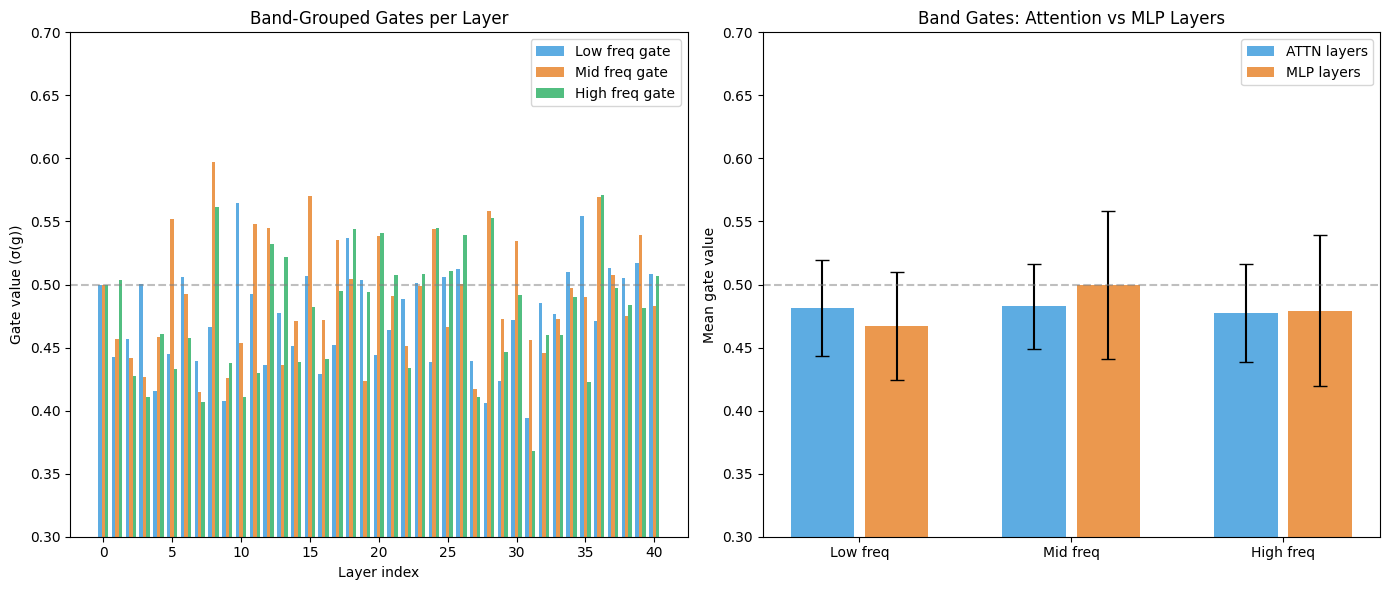

Saved: band_gate_chart.png


In [12]:
# ============================================================
# Cell 12 — Band Gate Visualization
# ============================================================
if os.path.exists("band_gate_analysis.csv"):
    gate_df = pd.read_csv("band_gate_analysis.csv")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Per-layer band gates
    ax = axes[0]
    x = np.arange(len(gate_df))
    w = 0.25
    ax.bar(x - w, gate_df["gate_low"], w, label="Low freq gate", color="#3498db", alpha=0.8)
    ax.bar(x, gate_df["gate_mid"], w, label="Mid freq gate", color="#e67e22", alpha=0.8)
    ax.bar(x + w, gate_df["gate_high"], w, label="High freq gate", color="#27ae60", alpha=0.8)
    ax.set_xlabel("Layer index")
    ax.set_ylabel("Gate value (σ(g))")
    ax.set_title("Band-Grouped Gates per Layer")
    ax.legend()
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylim(0.3, 0.7)
    
    # Plot 2: MLP vs Attention comparison
    ax = axes[1]
    for i, lt in enumerate(["attn", "mlp"]):
        sub = gate_df[gate_df["layer_type"] == lt]
        if len(sub) > 0:
            means = [sub["gate_low"].mean(), sub["gate_mid"].mean(), sub["gate_high"].mean()]
            stds = [sub["gate_low"].std(), sub["gate_mid"].std(), sub["gate_high"].std()]
            x_pos = np.arange(3) + i * 0.35
            ax.bar(x_pos, means, 0.3, yerr=stds, label=f"{lt.upper()} layers",
                   color=["#3498db", "#e67e22"][i], alpha=0.8, capsize=5)
    
    ax.set_xticks([0.175, 1.175, 2.175])
    ax.set_xticklabels(["Low freq", "Mid freq", "High freq"])
    ax.set_ylabel("Mean gate value")
    ax.set_title("Band Gates: Attention vs MLP Layers")
    ax.legend()
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylim(0.3, 0.7)
    
    plt.tight_layout()
    plt.savefig("band_gate_chart.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: band_gate_chart.png")
else:
    print("No gate analysis data found — run FreqLoRA mode first.")
